# Linear Regression from Scratch (Python / NumPy)

This notebook implements **simple linear regression** from scratch using:

1. **Gradient Descent** (iterative optimization)
2. **Normal Equation** (closed-form solution)

We also visualize the fit and compute error metrics.


In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# Example dataset 
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 5, 4, 5], dtype=float)

n = len(X)
print("n =", n)


n = 5


plt.figure()
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Training Data")
plt.show()


## Model

We assume a linear relationship:

$$
\hat{y} = wx + b
$$

## Loss (Mean Squared Error)

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2
$$



In [10]:
def predict(X, w, b):
    return w * X + b

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot


## Gradient Descent

We minimize the mean squared error by iteratively updating the parameters:

$$
w \leftarrow w - \alpha \frac{\partial J}{\partial w}, \quad
b \leftarrow b - \alpha \frac{\partial J}{\partial b}
$$

where $\alpha$ is the learning rate.

The gradients of the loss function are:

$$
\frac{\partial J}{\partial w}
= -\frac{2}{n} \sum_{i=1}^{n} x_i \left(y_i - \hat{y}_i\right)
$$

$$
\frac{\partial J}{\partial b}
= -\frac{2}{n} \sum_{i=1}^{n} \left(y_i - \hat{y}_i\right)
$$



In [12]:
# Hyperparameters
lr = 0.05
epochs = 2000

# Initialize
w = 0.0
b = 0.0

loss_history = []

for epoch in range(epochs):
    y_hat = predict(X, w, b)

    # gradients
    dw = (-2/n) * np.sum(X * (y - y_hat))
    db = (-2/n) * np.sum(y - y_hat)

    # update
    w -= lr * dw
    b -= lr * db

    # store loss
    loss = mse(y, y_hat)
    loss_history.append(loss)

    # optional logging
    if epoch % 200 == 0:
        print(f"epoch={epoch:4d}  loss={loss:.6f}  w={w:.4f}  b={b:.4f}")

print("\nFinal parameters (GD):")
print("w =", w)
print("b =", b)


epoch=   0  loss=17.200000  w=1.3200  b=0.4000
epoch= 200  loss=0.480709  w=0.6170  b=2.1386
epoch= 400  loss=0.480001  w=0.6006  b=2.1980
epoch= 600  loss=0.480000  w=0.6000  b=2.1999
epoch= 800  loss=0.480000  w=0.6000  b=2.2000
epoch=1000  loss=0.480000  w=0.6000  b=2.2000
epoch=1200  loss=0.480000  w=0.6000  b=2.2000
epoch=1400  loss=0.480000  w=0.6000  b=2.2000
epoch=1600  loss=0.480000  w=0.6000  b=2.2000
epoch=1800  loss=0.480000  w=0.6000  b=2.2000

Final parameters (GD):
w = 0.6000000000000033
b = 2.1999999999999877


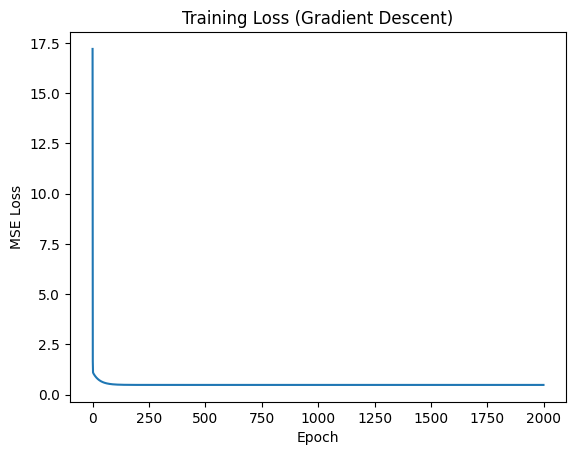

In [13]:
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss (Gradient Descent)")
plt.show()


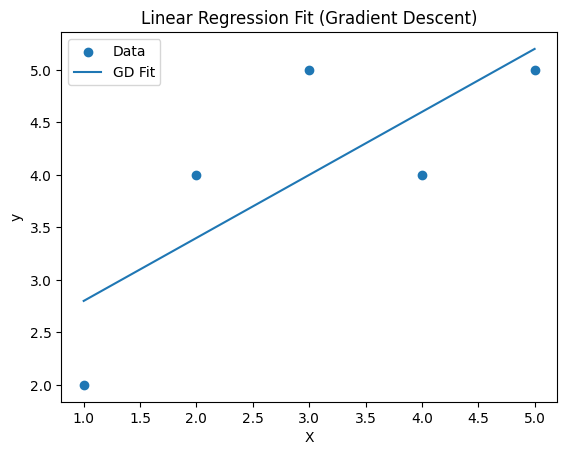

In [14]:
y_pred_gd = predict(X, w, b)

plt.figure()
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred_gd, label="GD Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Fit (Gradient Descent)")
plt.legend()
plt.show()


In [15]:
print("Metrics (Gradient Descent):")
print("MSE =", mse(y, y_pred_gd))
print("R^2 =", r2_score(y, y_pred_gd))


Metrics (Gradient Descent):
MSE = 0.4800000000000001
R^2 = 0.5999999999999999


## Closed-form Solution (Normal Equation)

For linear regression, the optimal parameters can be obtained by solving the normal equation:

$$
\boldsymbol{\theta} = (X^\top X)^{-1} X^\top \mathbf{y}
$$

where $X \in \mathbb{R}^{n \times p}$ is the design matrix,
$\mathbf{y} \in \mathbb{R}^{n}$ is the response vector, and
$\boldsymbol{\theta} \in \mathbb{R}^{p}$ contains the model parameters.



In [16]:
X_b = np.c_[np.ones((n, 1)), X]  # shape (n, 2): [1, x]

theta = np.linalg.inv(X_b.T @ X_b) @ (X_b.T @ y)

b_ne, w_ne = theta[0], theta[1]

print("Normal Equation parameters:")
print("w =", w_ne)
print("b =", b_ne)

y_pred_ne = predict(X, w_ne, b_ne)

print("\nMetrics (Normal Equation):")
print("MSE =", mse(y, y_pred_ne))
print("R^2 =", r2_score(y, y_pred_ne))


Normal Equation parameters:
w = 0.6000000000000004
b = 2.200000000000004

Metrics (Normal Equation):
MSE = 0.48000000000000015
R^2 = 0.5999999999999999


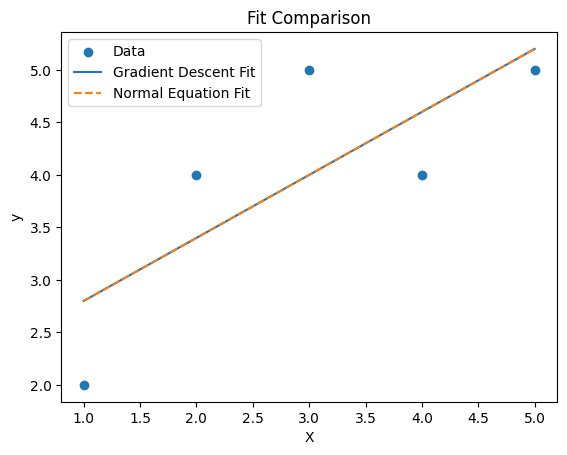

In [17]:
plt.figure()
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred_gd, label="Gradient Descent Fit")
plt.plot(X, y_pred_ne, "--", label="Normal Equation Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Fit Comparison")
plt.legend()
plt.show()
